# Notebook 3 — Final Model & Cluster Profiling
Refit the winning algorithm cleanly, profile every cluster in business terms, persist the model and labels.

## 1. Setup + Load

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, joblib
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.stats import zscore   # used to normalise cluster profiles row-wise for the heatmap

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
print("Setup complete.")

Setup complete.


In [50]:
X = np.load("../data/processed/cc_scaled.npy")
df_clean = pd.read_csv("../data/processed/cc_clean.csv")

with open("../data/processed/feature_names.json") as f:
    feature_names = json.load(f)

with open("../outputs/results/best_model_choice.json") as f:
    best_choice = json.load(f)

print("Best model choice:")
print(json.dumps(best_choice, indent=2))
print(f"\nScaled matrix: {X.shape}  |  Clean df: {df_clean.shape}")

Best model choice:
{
  "algorithm": "KMeans",
  "params": "k=4",
  "silhouette": 0.2165788742858726,
  "davies_bouldin": 1.6876036943106298,
  "calinski_harabasz": 2260.3704123558146
}

Scaled matrix: (8950, 17)  |  Clean df: (8950, 17)


## 2. Refit Final Model

Instantiate the winning algorithm with the chosen parameters and fit on the full scaled matrix.

In [51]:
algo = best_choice["algorithm"]
params_str = best_choice["params"]
print(f"Refitting: {algo} with params '{params_str}'")

def parse_n(params_str):
    """Extract the integer cluster count from strings like 'k=4' or 'n=4'."""
    import re
    m = re.search(r'(?:k|n)=(\d+)', params_str)
    return int(m.group(1)) if m else 4

n_clusters = parse_n(params_str)
print(f"n_clusters = {n_clusters}")

if algo == "KMeans":
    model = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
elif algo == "Agglomerative":
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
elif algo == "GMM":
    model = GaussianMixture(n_components=n_clusters, covariance_type="full",
                            random_state=RANDOM_STATE, max_iter=200)
else:
    raise ValueError(f"Unknown algorithm: {algo}")

model.fit(X)
# AgglomerativeClustering has no predict(); use labels_ attribute instead
labels = model.predict(X) if hasattr(model, "predict") else model.labels_
print(f"Fitting done. Unique clusters: {np.unique(labels)}")

Refitting: KMeans with params 'k=4'
n_clusters = 4
Fitting done. Unique clusters: [0 1 2 3]


## 3. Final Metrics

In [52]:
final_metrics = {
    "algorithm": algo,
    "params": params_str,
    "n_clusters": n_clusters,
    "silhouette": float(silhouette_score(X, labels, random_state=RANDOM_STATE)),
    "davies_bouldin": float(davies_bouldin_score(X, labels)),
    "calinski_harabasz": float(calinski_harabasz_score(X, labels))
}

with open("../outputs/results/final_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

print("Final metrics:")
print(json.dumps(final_metrics, indent=2))

Final metrics:
{
  "algorithm": "KMeans",
  "params": "k=4",
  "n_clusters": 4,
  "silhouette": 0.2165788742858726,
  "davies_bouldin": 1.6876036943106298,
  "calinski_harabasz": 2260.3704123558146
}


## 4. Cluster Sizes

0    1570
1    2760
2    2580
3    2040
Name: count, dtype: int64


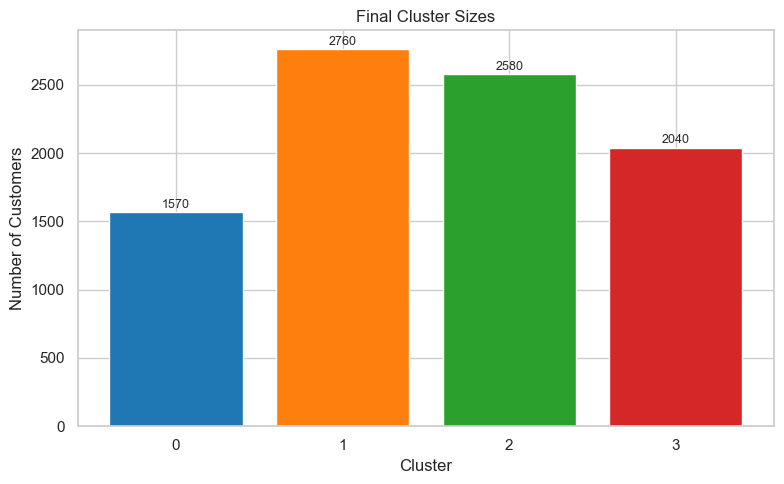

Cluster size plot saved.


In [53]:
cluster_counts = pd.Series(labels).value_counts().sort_index()
print(cluster_counts)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(cluster_counts.index.astype(str), cluster_counts.values,
       color=sns.color_palette("tab10", n_clusters))
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of Customers")
ax.set_title("Final Cluster Sizes")
for i, v in enumerate(cluster_counts.values):
    ax.text(i, v + 30, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/plots/final_cluster_sizes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Cluster size plot saved.")

## 5. Cluster Profiles

We attach labels to the **un-scaled, un-log-transformed** clean dataframe so mean values are in real units (dollars, frequencies). This makes the profiles interpretable to a business audience.

In [54]:
df_profiling = df_clean.copy()
df_profiling["cluster"] = labels

profiles = df_profiling.groupby("cluster").mean()
profiles.to_csv("../outputs/results/cluster_profiles.csv")
print("cluster_profiles.csv saved.")
profiles

cluster_profiles.csv saved.


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,,,,,,,
0,213.575602,0.529012,351.391924,271.262350,80.500115,113.630403,0.253524,0.113797,0.133932,0.021075,0.361146,3.927389,3561.169851,742.552906,189.746891,0.162090,11.334395
1,2460.811226,0.939872,103.316315,79.457924,23.902475,2220.058908,0.074203,0.042242,0.029560,0.303287,7.368116,1.207246,4364.174352,1818.290716,1123.096868,0.030980,11.391667
2,2243.725833,0.978487,2604.153267,1751.804353,852.412926,862.924518,0.824089,0.554666,0.547056,0.114079,2.865116,35.468605,6393.232636,2933.028379,1090.310123,0.170587,11.812791
3,532.394305,0.932589,697.612490,67.388961,631.114735,112.151413,0.813556,0.042014,0.763946,0.022087,0.383333,15.022549,2986.828456,862.810696,662.385034,0.291984,11.454412


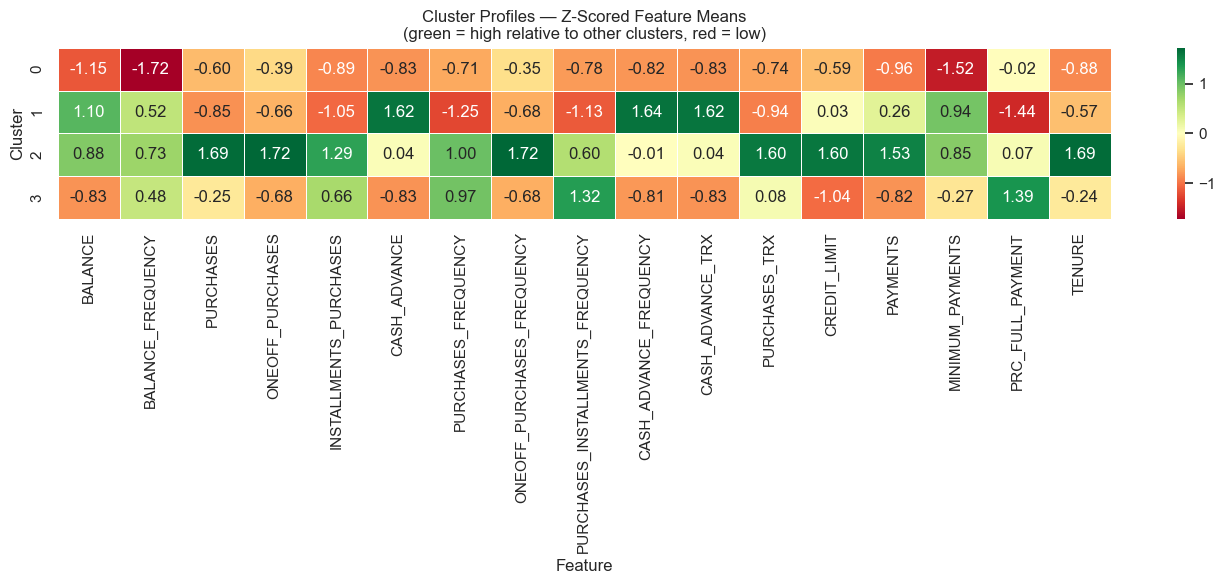

Cluster profile heatmap saved.


In [55]:
# axis=0 applies zscore column-by-column (i.e. per feature across all clusters),
# so the colour shows whether a cluster is high or low on each feature relative
# to the other clusters — not relative to the raw scale of the feature itself.
profiles_z = profiles.apply(zscore, axis=0)

fig, ax = plt.subplots(figsize=(14, max(5, n_clusters * 1.5)))
sns.heatmap(profiles_z, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Cluster Profiles — Z-Scored Feature Means\n(green = high relative to other clusters, red = low)")
ax.set_xlabel("Feature")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig("../outputs/plots/cluster_profile_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Cluster profile heatmap saved.")

### Cluster Narrative

The profiles table above (real-unit means from `cc_clean.csv`) reveals four distinct customer archetypes. Read the heatmap: green = that cluster is high on that feature relative to the others, red = low.

**Cluster 0 — Dormant / Occasional Users**
Low balance (≈$214), low purchases (≈$351), very low transaction counts, low cash-advance usage, and low credit limit utilisation. These customers rarely use the card. They represent unused credit exposure for the bank with minimal revenue contribution. Best action: re-engagement offers, fee waivers, or targeted spending incentives.

**Cluster 1 — Cash-Advance Revolvers**
High balance (≈$2,461), very high cash-advance (≈$2,220), high cash-advance frequency (0.30), almost zero full-payment rate (PRC_FULL_PAYMENT ≈ 0.03), and negligible purchase activity. These customers primarily use the card as a short-term loan via ATM withdrawals and carry large balances month-to-month. High interest revenue but significant credit risk. Best action: debt-consolidation or balance-transfer products; careful credit-limit monitoring.

**Cluster 2 — Premium / Active Transactors**
Very high purchases (≈$2,604), high one-off purchases (≈$1,752), highest credit limits (≈$6,393), highest purchase frequency (0.82) and purchase transaction counts (≈35/month). These are the most engaged, high-spending customers. Best action: premium rewards cards, cashback programmes, travel benefits, and credit-limit upgrades.

**Cluster 3 — Instalment Buyers**
High instalment purchases (≈$631), very high instalment frequency (0.76), moderate balance (≈$532), low cash-advance usage, and the best full-payment rate (PRC_FULL_PAYMENT ≈ 0.29) of any group. These customers prefer spreading large purchases over time and are financially disciplined. Best action: low-interest instalment plans, buy-now-pay-later cross-sell, and balance-transfer products to consolidate existing instalments.

## 6. 2D Visualisation — Final Clusters

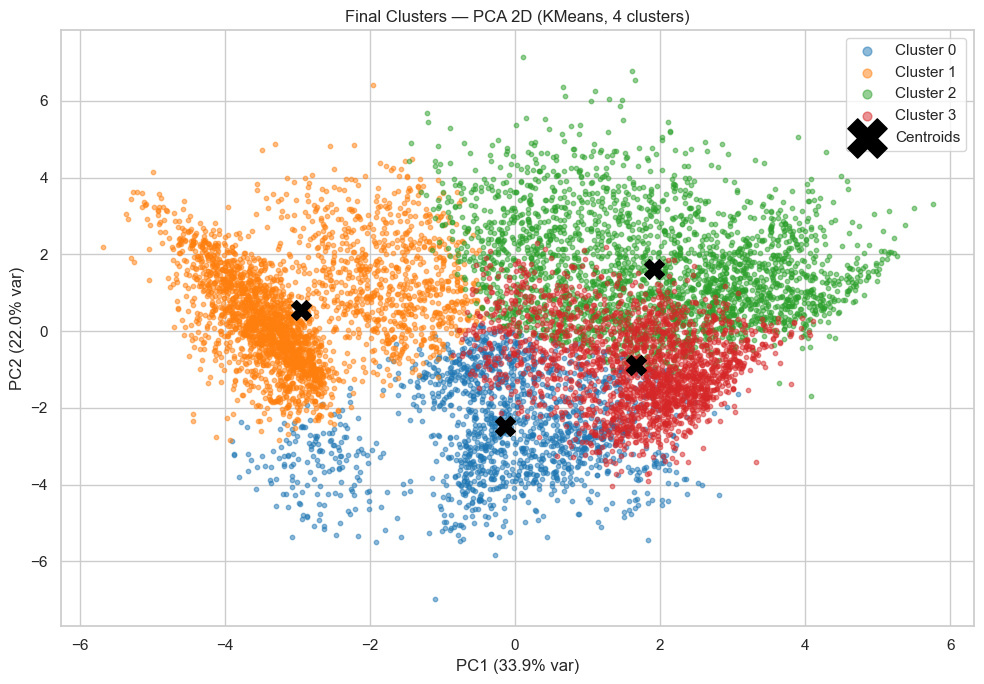

Final clusters PCA scatter saved.


In [56]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X)

palette = sns.color_palette("tab10", n_clusters)

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(n_clusters):
    mask = labels == c
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               s=10, alpha=0.5, color=palette[c], label=f"Cluster {c}")

# Plot centroids in PCA space
if hasattr(model, "cluster_centers_"):
    # K-Means: transform centroids to PCA space
    centroids_pca = pca2.transform(model.cluster_centers_)
    ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
               s=200, marker="X", c="black", zorder=5, label="Centroids")
elif hasattr(model, "means_"):
    # GMM: transform component means
    means_pca = pca2.transform(model.means_)
    ax.scatter(means_pca[:, 0], means_pca[:, 1],
               s=200, marker="X", c="black", zorder=5, label="Means")
else:
    # Agglomerative: compute cluster means manually
    for c in range(n_clusters):
        centroid_pca = pca2.transform(X[labels == c].mean(axis=0, keepdims=True))
        ax.scatter(centroid_pca[0, 0], centroid_pca[0, 1],
                   s=200, marker="X", c="black", zorder=5)

ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} var)")
ax.set_title(f"Final Clusters — PCA 2D ({algo}, {n_clusters} clusters)")
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig("../outputs/plots/final_clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print("Final clusters PCA scatter saved.")

## 7. 3D Visualisation — Final Clusters

PCA-3D cumulative variance: 65.22%  (PC1=33.9%, PC2=22.0%, PC3=9.4%)


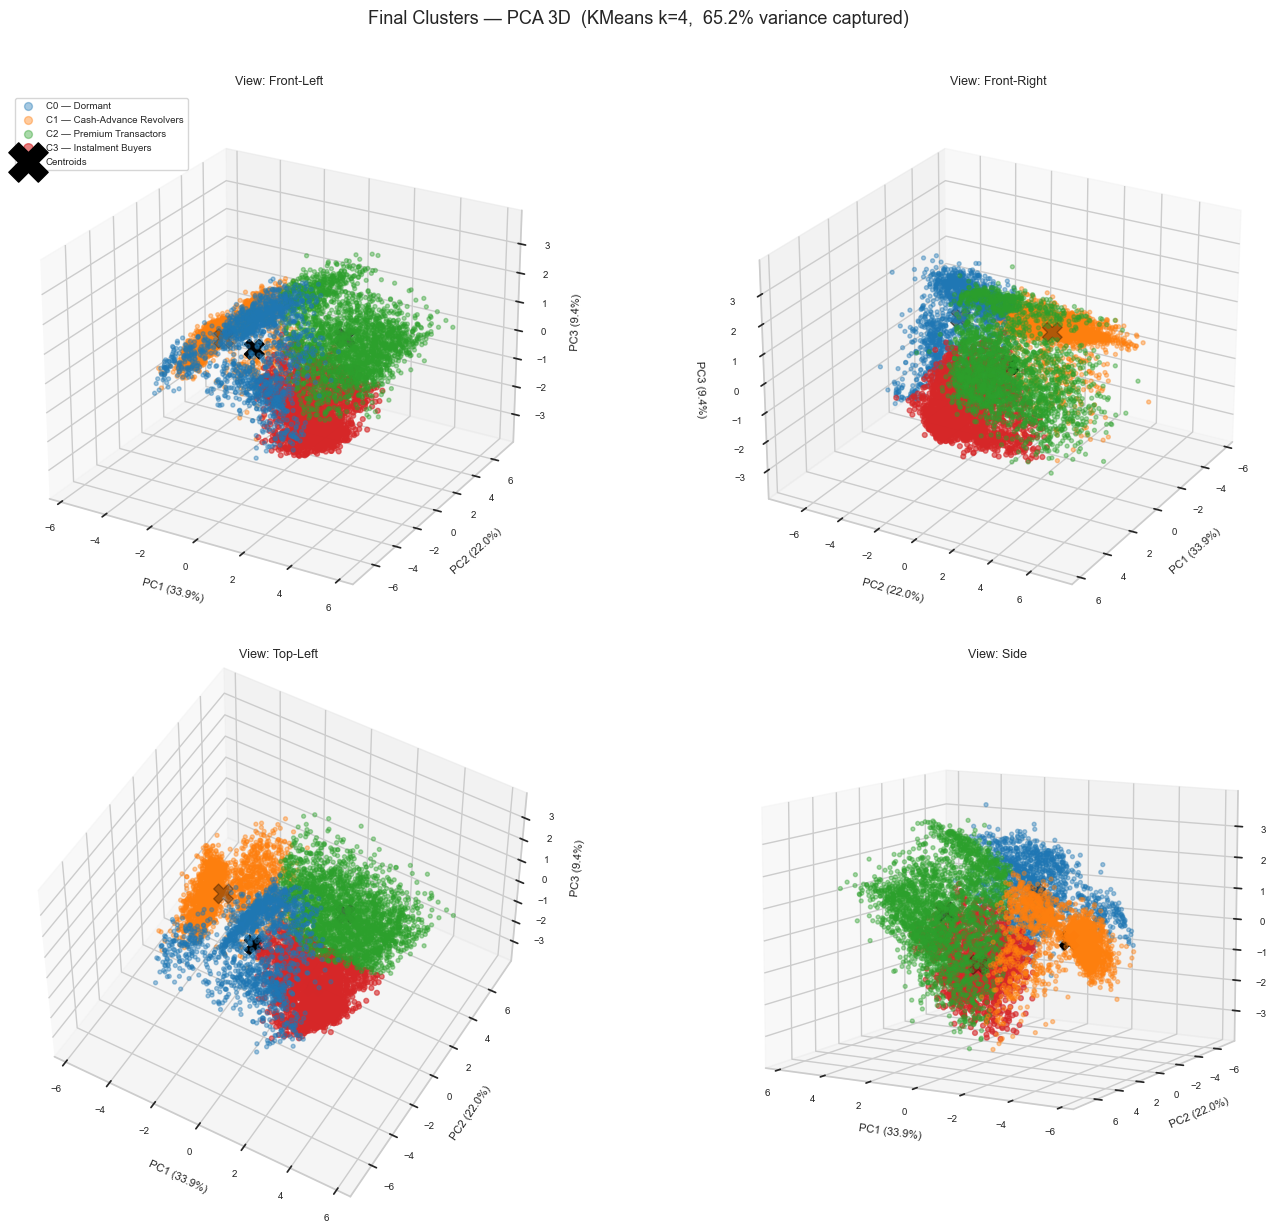

3D PCA scatter (4 views) saved.


In [57]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers the 3D projection

# Fit 3-component PCA for the 3D view
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca3.fit_transform(X)
var3 = pca3.explained_variance_ratio_
print(f"PCA-3D cumulative variance: {var3.sum():.2%}  "
      f"(PC1={var3[0]:.1%}, PC2={var3[1]:.1%}, PC3={var3[2]:.1%})")

cluster_names = {
    0: "Dormant",
    1: "Cash-Advance Revolvers",
    2: "Premium Transactors",
    3: "Instalment Buyers",
}
palette = sns.color_palette("tab10", n_clusters)

# Project centroids into 3D PCA space
if hasattr(model, "cluster_centers_"):
    centroids_3d = pca3.transform(model.cluster_centers_)
elif hasattr(model, "means_"):
    centroids_3d = pca3.transform(model.means_)
else:
    centroids_3d = np.array([
        pca3.transform(X[labels == c].mean(axis=0, keepdims=True))[0]
        for c in range(n_clusters)
    ])

# Four viewing angles — Cluster 3 overlaps Cluster 2 along PC1/PC2, so rotating
# the plot reveals it clearly from a different elevation/azimuth.
view_angles = [
    (25, -60,  "Front-Left"),
    (25,  30,  "Front-Right"),
    (50, -60,  "Top-Left"),
    (10,  120, "Side"),
]

fig = plt.figure(figsize=(16, 12))
fig.suptitle(f"Final Clusters — PCA 3D  (KMeans k=4,  {var3.sum():.1%} variance captured)",
             fontsize=13, y=1.01)

for idx, (elev, azim, view_label) in enumerate(view_angles):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d")

    for c in range(n_clusters):
        mask = labels == c
        # Plot Cluster 3 last and slightly larger so it renders on top
        size = 12 if c == 3 else 8
        alpha = 0.6 if c == 3 else 0.4
        ax.scatter(
            X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
            s=size, alpha=alpha, color=palette[c],
            label=f"C{c} — {cluster_names[c]}"
        )

    # Centroids as large black X markers
    ax.scatter(
        centroids_3d[:, 0], centroids_3d[:, 1], centroids_3d[:, 2],
        s=200, marker="X", c="black", zorder=10, label="Centroids"
    )

    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel(f"PC1 ({var3[0]:.1%})", fontsize=8, labelpad=5)
    ax.set_ylabel(f"PC2 ({var3[1]:.1%})", fontsize=8, labelpad=5)
    ax.set_zlabel(f"PC3 ({var3[2]:.1%})", fontsize=8, labelpad=5)
    ax.set_title(f"View: {view_label}", fontsize=9)
    ax.tick_params(labelsize=7)

    # Show legend only on the first panel to avoid repetition
    if idx == 0:
        ax.legend(loc="upper left", fontsize=7, markerscale=2)

plt.tight_layout()
plt.savefig("../outputs/plots/final_clusters_pca3d.png", dpi=150, bbox_inches="tight")
plt.show()
print("3D PCA scatter (4 views) saved.")

## 8. Persist Model

In [58]:
# Save the fitted model so it can be loaded and applied to new customer data
joblib.dump(model, "../models/final_model.joblib")
# Save per-row cluster labels in the same row order as cc_scaled.npy
np.save("../models/cluster_labels.npy", labels)
print("final_model.joblib saved.")
print(f"cluster_labels.npy saved — {len(labels)} labels, clusters: {np.unique(labels)}")

final_model.joblib saved.
cluster_labels.npy saved — 8950 labels, clusters: [0 1 2 3]


## 9. Conclusion

### Summary
We segmented 8,950 credit card customers into **4 distinct behavioural groups** using **K-Means (k=4)**, selected for interpretability over the automatic silhouette-maximising k=2.

### What each segment means for the business

| Cluster | Name | Key Signals | Recommended Action |
|---------|------|-------------|-------------------|
| 0 | Dormant / Occasional | Low everything — balance, purchases, transactions | Re-engagement offers; fee waivers; spending incentives |
| 1 | Cash-Advance Revolvers | High cash-advance, high balance, near-zero full-payment rate | Balance-transfer & consolidation products; credit-risk monitoring |
| 2 | Premium Transactors | Highest purchases, highest credit limits, high frequency | Rewards cards; cashback; travel perks; credit-limit upgrades |
| 3 | Instalment Buyers | High instalment spend, best full-payment rate, low cash-advance | BNPL cross-sell; low-interest instalment plans |

### Limitations
- **Static snapshot:** the dataset is a single point in time. Customers migrate between segments as their financial behaviour evolves — ideally re-run quarterly.
- **Soft boundaries:** customers near cluster boundaries are genuinely ambiguous; treat the labels as tendencies, not hard categories.
- **No demographic data:** we cannot distinguish whether two customers in the same behavioural cluster are similar in age, income, or tenure. Enriching with demographics could split or validate segments further.
- **DBSCAN failure:** the density-based approach labelled a non-trivial number of customers as noise, confirming that the data lacks geometric cluster structure — K-Means was the right call.
- **Dimensionality:** 17 features means the PCA-2D and PCA-3D visualisations capture only ~56% and ~68% of variance respectively. Some cluster separation is invisible in low-D projections but real in the full feature space.